In [1]:
# Test fitting an old STIX flare with 1 keV with the albedo correction - using fixed sunkit_spex
# 
# From the sunkit-spex example
# https://sunkit-spex.readthedocs.io/en/latest/generated/gallery/legacy/fitting_STIX_spectra.html
# 

# 15-Jul-2026 IGH

In [2]:
from astropy.time import Time, TimeDelta
from astropy import units as u
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sunkit_spex.legacy import thermal
from sunkit_spex.extern.stix import STIXLoader
from sunkit_spex.legacy.fitting.fitter import Fitter
from sunkit_spex.legacy.fitting.albedo import get_albedo_matrix

from parfive import Downloader

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
plt.rcParams['font.size'] = 14

In [3]:
# dl = Downloader()
# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/stix/"
# file_names = [
#     "stx_spectrum_2410019944_IM.fits",
#     "stx_srm_2410019944_IM.fits",
#     "stx_spectrum_2410019944_BKG.fits",
#     "stx_srm_2410019944_BKG.fits",
# ]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="fits/")
# files = dl.download()

In [4]:
stix_spec = STIXLoader(
    spectrum_file="fits/stx_spectrum_2410019944_IM.fits", srm_file="fits/stx_srm_2410019944_IM.fits"
)

ftims=Time(['2024-10-01T22:10:10.000','2024-10-01T22:10:18.000'],format='isot')
btims=Time(['2024-10-01T22:00:00','2024-10-01T22:01:00.000'],format='isot')

stix_spec.update_background_times(btims[0],btims[1])
stix_spec.update_event_times(ftims[0],ftims[1])

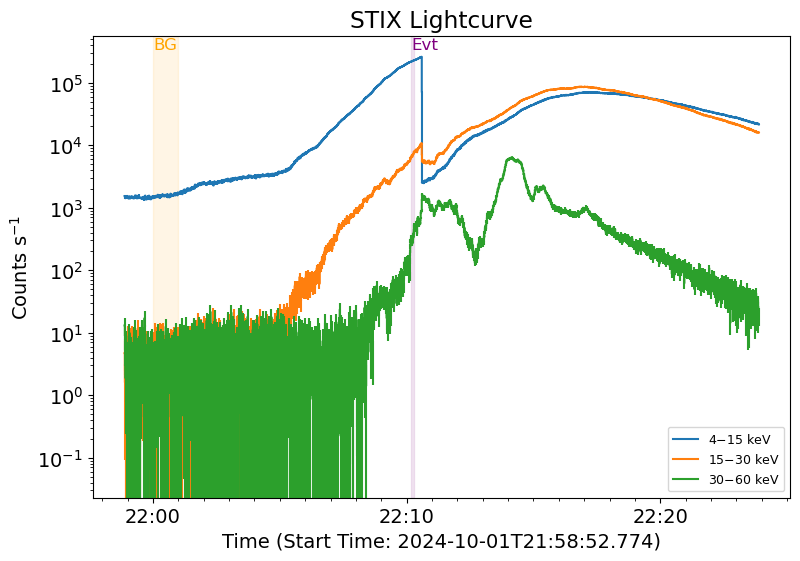

In [5]:
plt.figure(figsize=(9,6))
ax=stix_spec.lightcurve(energy_ranges=[[4, 15], [15, 30], [30, 60]])
ax.xaxis.set_minor_locator(matplotlib.dates.MinuteLocator(interval=1))
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=10))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
plt.show()

In [6]:
fitter = Fitter(stix_spec)
fitter.albedo_corr=True
fitter.albedo_angle=76 * u.deg

fitter.model = "(f_vth + f_vth + thick_fn)"
fitter.loglikelihood = "chi2" # to match doc example, but normally cstat for this, and RHESSI?

In [7]:
fitter.energy_fitting_range = [4, 84]

# sort model parameters
fitter.params["T1_spectrum1"] = {"Value": 19, "Bounds": (13, 30), "Status": "free"}
fitter.params["EM1_spectrum1"] = {"Value": 470, "Bounds": (300, 800), "Status": "free"}
fitter.params["T2_spectrum1"] = {"Value": 40, "Bounds": (20, 60), "Status": "free"}
fitter.params["EM2_spectrum1"] = {"Value": 7, "Bounds": (3, 20), "Status": "free"}
fitter.params["total_eflux1_spectrum1"] = {"Value": 4, "Bounds": (1, 10), "Status": "free"}
fitter.params["index1_spectrum1"] = {"Value": 4, "Bounds": (2, 15), "Status": "free"}
fitter.params["e_c1_spectrum1"] = {"Value": 17, "Bounds": (10, 27), "Status": "free"}

spec_fit = fitter.fit(tol=1e-20)

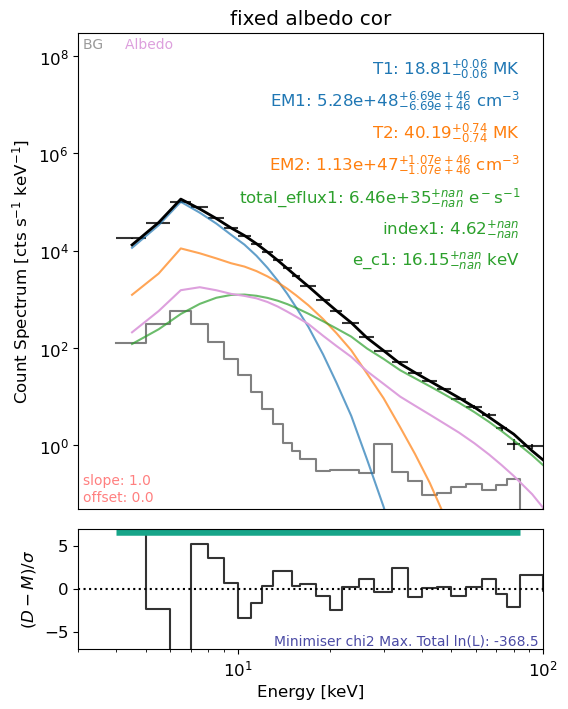

In [8]:
xlims, ylims = [3,100], [5e-2,3e8]
plt.rcParams['font.size'] = 12
plt.figure(figsize=(6,8))
axes, res_axes = fitter.plot()
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
axes[0].set_title('fixed albedo cor')
plt.show()

In [9]:
fitter.save('fit_saves/sks_stxold_fix.pickle')

In [10]:
import sunpy
import sunkit_spex
print("SunPy:", sunpy.__version__)
print("sunkit_spex:", sunkit_spex.__version__)

SunPy: 8.0.0
sunkit_spex: 0.5.1.dev12+ge7a7fec9b.d20260716
